In [1]:
import cygnet
import numpy as np
import torch, time, os
from torch.utils.data import DataLoader
import torch.nn.functional as F
from matplotlib import pyplot as plt

use_mixed_precision = False

def test_loss(pred, target):
    return cygnet.focal_loss(pred, target)

cygnet.start_timer()

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
torch.set_default_device(device)

b_size = 32
num_batches = 1
epochs = 1

H = 2304 // 4
W = 4096 // 4

data = [torch.randn(b_size, 1, H, W) for _ in range(num_batches)]
targets = [torch.randn(b_size, 1, H, W) for _ in range(num_batches)]
dummy = torch.randn(1, 1, H, W)

cygnet.end_timer_and_print("setup")
print("\n=======\n")
cygnet.start_timer()

net = cygnet.Net(32)
opt = torch.optim.SGD(net.parameters(), lr=0.001)
scaler = torch.amp.GradScaler("cuda", enabled=use_mixed_precision)

print(net)

b = 0
for epoch in range(epochs):
    print(f"start epoch {epoch}:")
    net.train()
    for input, target in zip(data, targets):
        print(f"batch #{b}")
        b += 1
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_mixed_precision):
            output = net(input)
            loss = test_loss(output, target)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        opt.zero_grad()
cygnet.end_timer_and_print("Mixed precision:")

net.eval()
# Warmup
for _ in range(10):
    _ = net(dummy)

torch.cuda.synchronize()
t0 = time.perf_counter()
for _ in range(10):
    with torch.inference_mode(), torch.autocast(device_type=device, dtype=torch.float16, enabled=use_mixed_precision):
        _ = net(dummy)
torch.cuda.synchronize()
tim = (time.perf_counter() - t0) / 10 * 1000
print(f"in inference: {tim:.1f} ms per frame")

Using cuda device

setup
Total execution time = 0.010 sec
Max memory used by tensors = 0.143 Gbytes


Net(
  (bn_input): BatchNorm2d(1, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dc1): DoubleDown2(
    (seq): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
    )
    (mp): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (dc2): DoubleDown2(
    (seq): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=Tr

4200
700
700
tensor(0.0029, device='cuda:0') tensor(0.0060, device='cuda:0')
<class 'torchvision.tv_tensors._image.Image'>
<class 'torchvision.tv_tensors._image.Image'>


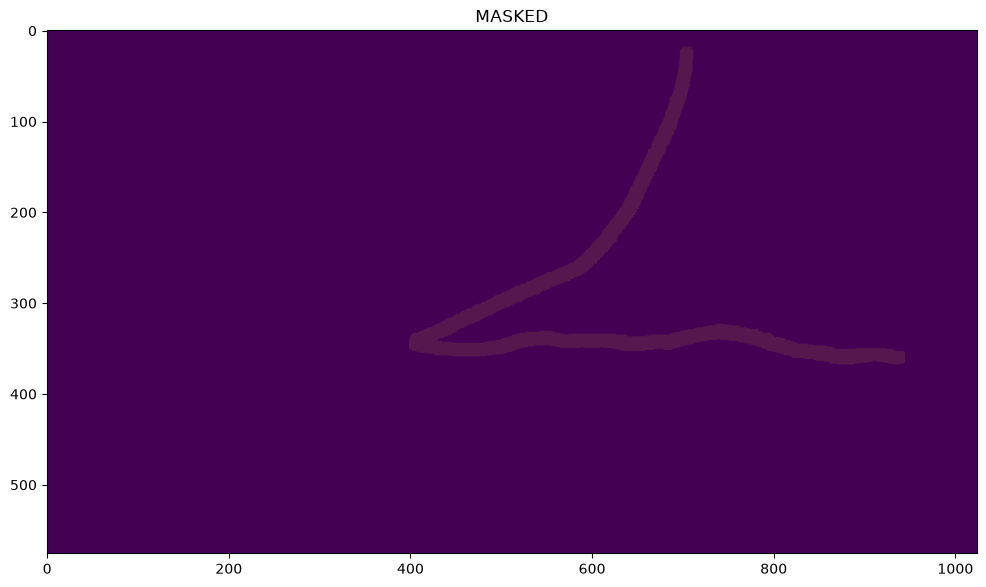

In [2]:
# paths
train_path = "/home/frx/dataset/image_dataset/train"
vali_path = "/home/frx/dataset/image_dataset/vali"
test_path = "/home/frx/dataset/image_dataset/test"

# folders:
input_path = "input"
mask_path = "mask"
mask_exp2_path = "mask_exp2"
mask_exp4_path = "mask_exp4"

# change this
target_path = mask_exp4_path

input_train_path = os.path.join(train_path, input_path)
target_train_path = os.path.join(train_path, target_path)

input_vali_path = os.path.join(vali_path, input_path)
target_vali_path = os.path.join(vali_path, target_path)

input_test_path = os.path.join(test_path, input_path)
target_test_path = os.path.join(test_path, target_path)

train_dset = cygnet.CygnoSet(input_train_path, target_train_path)
print(len(train_dset))
vali_dset = cygnet.CygnoSet(input_vali_path, target_vali_path)
print(len(vali_dset))
test_dset = cygnet.CygnoSet(input_test_path, target_test_path)
print(len(test_dset))

image, mask = train_dset[1]

print(image.min(), image.max())
print(type(mask))
print(type(image))

cygnet.debug_plot(image.cpu().squeeze(), mask.cpu().squeeze())
# cygnet.debug_plot(image.cpu().squeeze(), mask.cpu().squeeze())

recompute = False
summax = []
summin = []
if recompute:
	for ii in range(len(train_dset)):
		im, _ = train_dset[ii]
		im = im.cpu()
		summax.append(im.max())
		summin.append(im.min())

	summax = np.array(summax)
	summin = np.array(summin)

	avgmax = summax.sum()/len(train_dset)
	avgmin = summin.sum()/len(train_dset)
	absmax = summax.max()
	absmin = summin.min()

	print(f"avgmax = {avgmax}, absmax = {absmax}")
	print(f"avgmin = {avgmin}, absmin = {absmin}")
	# avgmax = 393.4752502441406, absmax = 1097.0
	# avgmin = 192.07571411132812, absmin = 189.0
 
def total_loss(pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
    return cygnet.focal_loss(pred, target)


In [3]:
train_dloader = DataLoader(train_dset, batch_size=32, shuffle=True, num_workers=0, drop_last=True, generator=torch.Generator(device='cuda'),)
vali_dloader = DataLoader(vali_dset, batch_size=32, shuffle=True, num_workers=0, drop_last=True, generator=torch.Generator(device='cuda'),)
test_dloader = DataLoader(test_dset, batch_size=32, shuffle=True, num_workers=0, drop_last=True, generator=torch.Generator(device='cuda'),)

net.train()
print(f"device: {device}")
torch.backends.cudnn.benchmark = True
#optimizer = torch.optim.AdamW(net.parameters(), lr=0.1, weight_decay=1e-5)
optimizer = torch.optim.SGD(net.parameters(), lr=0.001)
scaler = torch.amp.GradScaler("cuda")

num_epochs = 10
tltot = []
vltot = []

for epoch in range(num_epochs):
    print(f"epoch {epoch+1} / {num_epochs}")
    net.train()
    
    train_loss_sum = 0
    vali_loss_sum = 0
    for imgs, masks in train_dloader:
        imgs  = imgs.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
 
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            preds = net(imgs)
            loss  = total_loss(preds, masks)
 
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        train_loss_sum += loss.item()
    
    tltot.append(train_loss_sum / len(train_dloader))
    print(f"train loss = {train_loss_sum / len(train_dloader)}")
 
    # validation
    net.eval()
    with torch.inference_mode():
        for imgs, masks in vali_dloader:
            imgs  = imgs.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                preds = net(imgs)
                val_loss = total_loss(preds, masks)
            vali_loss_sum += val_loss.item()
        vltot.append(vali_loss_sum / len(vali_dloader))
        print(f"vali loss = {vali_loss_sum / len(vali_dloader)}")

net.train()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)  # SGD, high lr, no scheduler

imgs, masks = next(iter(train_dloader))
imgs, masks = imgs.to(device), masks.to(device)

for step in range(20):
    pred = net(imgs)   # no autocast, no compile
    loss = total_loss(pred, masks)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)
    print(f"step {step:02d}: loss={loss.item():.6f}")

net.eval()
with torch.inference_mode():
    pred = net(imgs[:1])
    print(f"logit min: {pred.min():.3f}, max: {pred.max():.3f}, mean: {pred.mean():.3f}")

device: cuda
epoch 1 / 10
train loss = 0.04725015109390703
vali loss = 0.045336066612175534
epoch 2 / 10
train loss = 0.04382076703068864
vali loss = 0.04217999002763203
epoch 3 / 10
train loss = 0.04045887032651719
vali loss = 0.038742572778747195
epoch 4 / 10
train loss = 0.0367700946695022
vali loss = 0.03501801742684273
epoch 5 / 10
train loss = 0.03259329058457422
vali loss = 0.03056423410418488
epoch 6 / 10
train loss = 0.027990072069846036
vali loss = 0.025677924798358055
epoch 7 / 10
train loss = 0.02329129478289881
vali loss = 0.021304860090216
epoch 8 / 10
train loss = 0.019000039471469762
vali loss = 0.017424900528220905
epoch 9 / 10
train loss = 0.01553478500030878
vali loss = 0.014065770565399103
epoch 10 / 10
train loss = 0.012910849329453843
vali loss = 0.01183233427859488
step 00: loss=0.012397
step 01: loss=0.012227
step 02: loss=0.012066
step 03: loss=0.011914
step 04: loss=0.011762
step 05: loss=0.011620
step 06: loss=0.011472
step 07: loss=0.011331
step 08: loss=0.0

[0.04725015109390703, 0.04382076703068864, 0.04045887032651719, 0.0367700946695022, 0.03259329058457422, 0.027990072069846036, 0.02329129478289881, 0.019000039471469762, 0.01553478500030878, 0.012910849329453843]


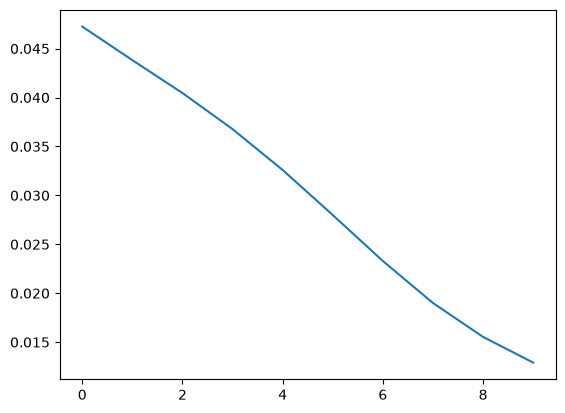

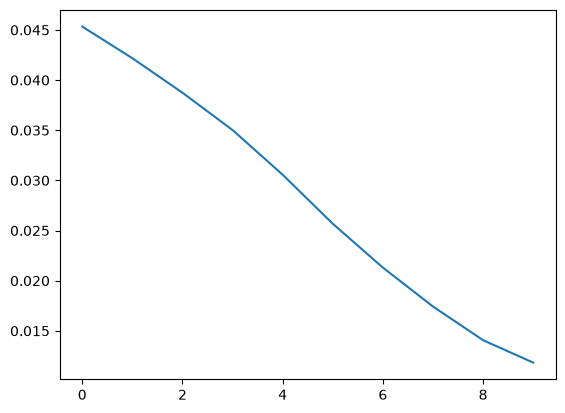

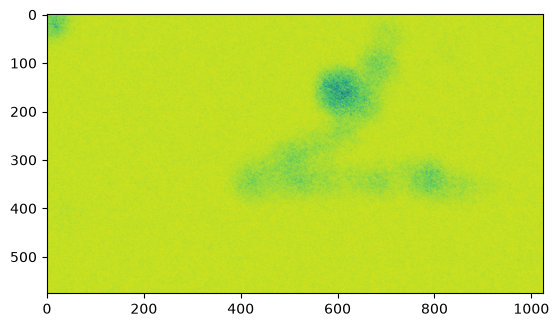

tensor(0.5462) tensor(-16.3893)


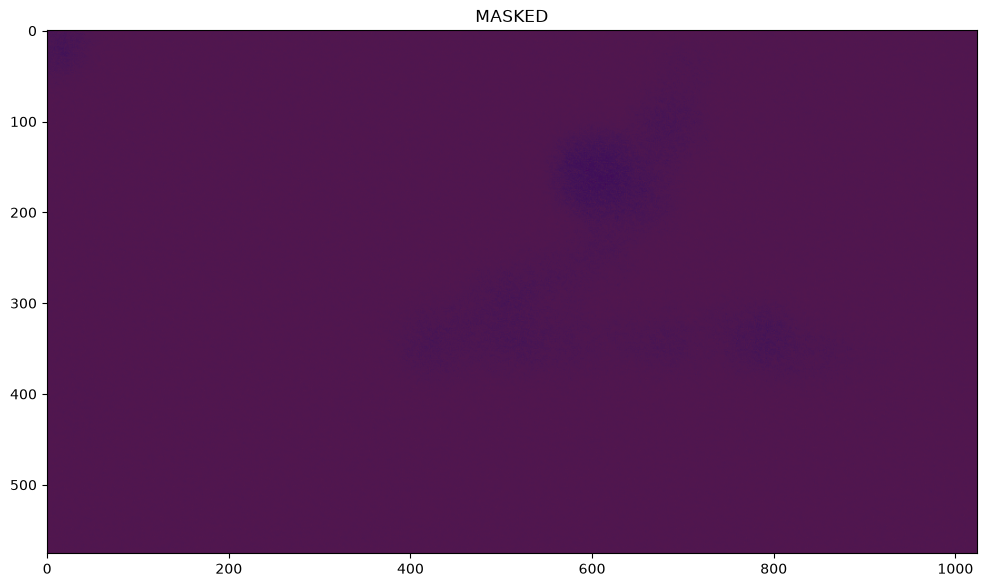

In [4]:
xt = [x for x in range(len(tltot))]
xv = [x for x in range(len(vltot))]

print(tltot)

plt.figure()
plt.plot(xt, tltot)
plt.show()

plt.figure()
plt.plot(xv, vltot)
plt.show()

pred = net(image.unsqueeze(0)).cpu().squeeze().detach()

plt.figure()
plt.imshow(pred)
plt.show()

print(pred.max(), pred.min())
cygnet.debug_plot(image.cpu().squeeze(), pred)